Para analizar el archivo breast_cancer_data.csv, se presenta a continuación un script en R diseñado para realizar un Análisis Exploratorio de Datos (EDA) exhaustivo. Este script utiliza el ecosistema tidyverse para la manipulación y visualización de datos, así como librerías especializadas en resúmenes estadísticos.

In [1]:
# -------------------------------------------------------------------------
# Script: Análisis Exploratorio de Datos (EDA) - Breast Cancer Data
# -------------------------------------------------------------------------

# 1. Carga de librerías necesarias
if (!require("tidyverse")) install.packages("tidyverse")
if (!require("skimr")) install.packages("skimr")
if (!require("corrplot")) install.packages("corrplot")
if (!require("reshape2")) install.packages("reshape2")

library(tidyverse)
library(skimr)
library(corrplot)
library(reshape2)

Loading required package: tidyverse
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Loading required package: skimr
Loading required package: corrplot
corrplot 0.95 loaded
Loading required package: reshape2

Attaching package: ‘reshape2’

The following object is masked from ‘package:tidyr’:

    smiths



In [2]:
# 2. Carga del conjunto de datos
# Se asume que el archivo se encuentra en el directorio de trabajo
data <- read.csv("../../data/breast_cancer_data.csv")

# 3. Inspección inicial
cat("--- Estructura del Dataset ---\n")
str(data)

cat("\n--- Primeras filas ---\n")
head(data)

# 4. Resumen estadístico completo
# skim() proporciona un resumen detallado que incluye histogramas en línea
cat("\n--- Resumen Estadístico Detallado ---\n")
skim(data)

--- Estructura del Dataset ---
'data.frame':	569 obs. of  31 variables:
 $ mean.radius            : num  18 20.6 19.7 11.4 20.3 ...
 $ mean.texture           : num  10.4 17.8 21.2 20.4 14.3 ...
 $ mean.perimeter         : num  122.8 132.9 130 77.6 135.1 ...
 $ mean.area              : num  1001 1326 1203 386 1297 ...
 $ mean.smoothness        : num  0.1184 0.0847 0.1096 0.1425 0.1003 ...
 $ mean.compactness       : num  0.2776 0.0786 0.1599 0.2839 0.1328 ...
 $ mean.concavity         : num  0.3001 0.0869 0.1974 0.2414 0.198 ...
 $ mean.concave.points    : num  0.1471 0.0702 0.1279 0.1052 0.1043 ...
 $ mean.symmetry          : num  0.242 0.181 0.207 0.26 0.181 ...
 $ mean.fractal.dimension : num  0.0787 0.0567 0.06 0.0974 0.0588 ...
 $ radius.error           : num  1.095 0.543 0.746 0.496 0.757 ...
 $ texture.error          : num  0.905 0.734 0.787 1.156 0.781 ...
 $ perimeter.error        : num  8.59 3.4 4.58 3.44 5.44 ...
 $ area.error             : num  153.4 74.1 94 27.2 94.4 ...
 $

── Data Summary ────────────────────────
                           Values
Name                       data  
Number of rows             569   
Number of columns          31    
_______________________          
Column type frequency:           
  numeric                  31    
________________________         
Group variables            None  

── Variable type: numeric ──────────────────────────────────────────────────────────────────────────────────────────────────────
   skim_variable           n_missing complete_rate      mean        sd         p0       p25       p50        p75      p100 hist 
 1 mean.radius                     0             1  14.1       3.52      6.98      11.7      13.4       15.8       28.1    ▂▇▃▁▁
 2 mean.texture                    0             1  19.3       4.30      9.71      16.2      18.8       21.8       39.3    ▃▇▃▁▁
 3 mean.perimeter                  0             1  92.0      24.3      43.8       75.2      86.2      104.       188.     ▃▇▃▁▁
 4 mean

In [3]:
# 5. Limpieza y Verificación de Datos
# Comprobar valores nulos
null_counts <- colSums(is.na(data))
cat("\n--- Valores nulos por columna ---\n")
print(null_counts)

# Convertir la variable 'target' a factor para análisis categórico
# Generalmente: 0 = Maligno, 1 = Benigno
data$target <- as.factor(data$target)


--- Valores nulos por columna ---
            mean.radius            mean.texture          mean.perimeter               mean.area         mean.smoothness 
                      0                       0                       0                       0                       0 
       mean.compactness          mean.concavity     mean.concave.points           mean.symmetry  mean.fractal.dimension 
                      0                       0                       0                       0                       0 
           radius.error           texture.error         perimeter.error              area.error        smoothness.error 
                      0                       0                       0                       0                       0 
      compactness.error         concavity.error    concave.points.error          symmetry.error fractal.dimension.error 
                      0                       0                       0                       0                       

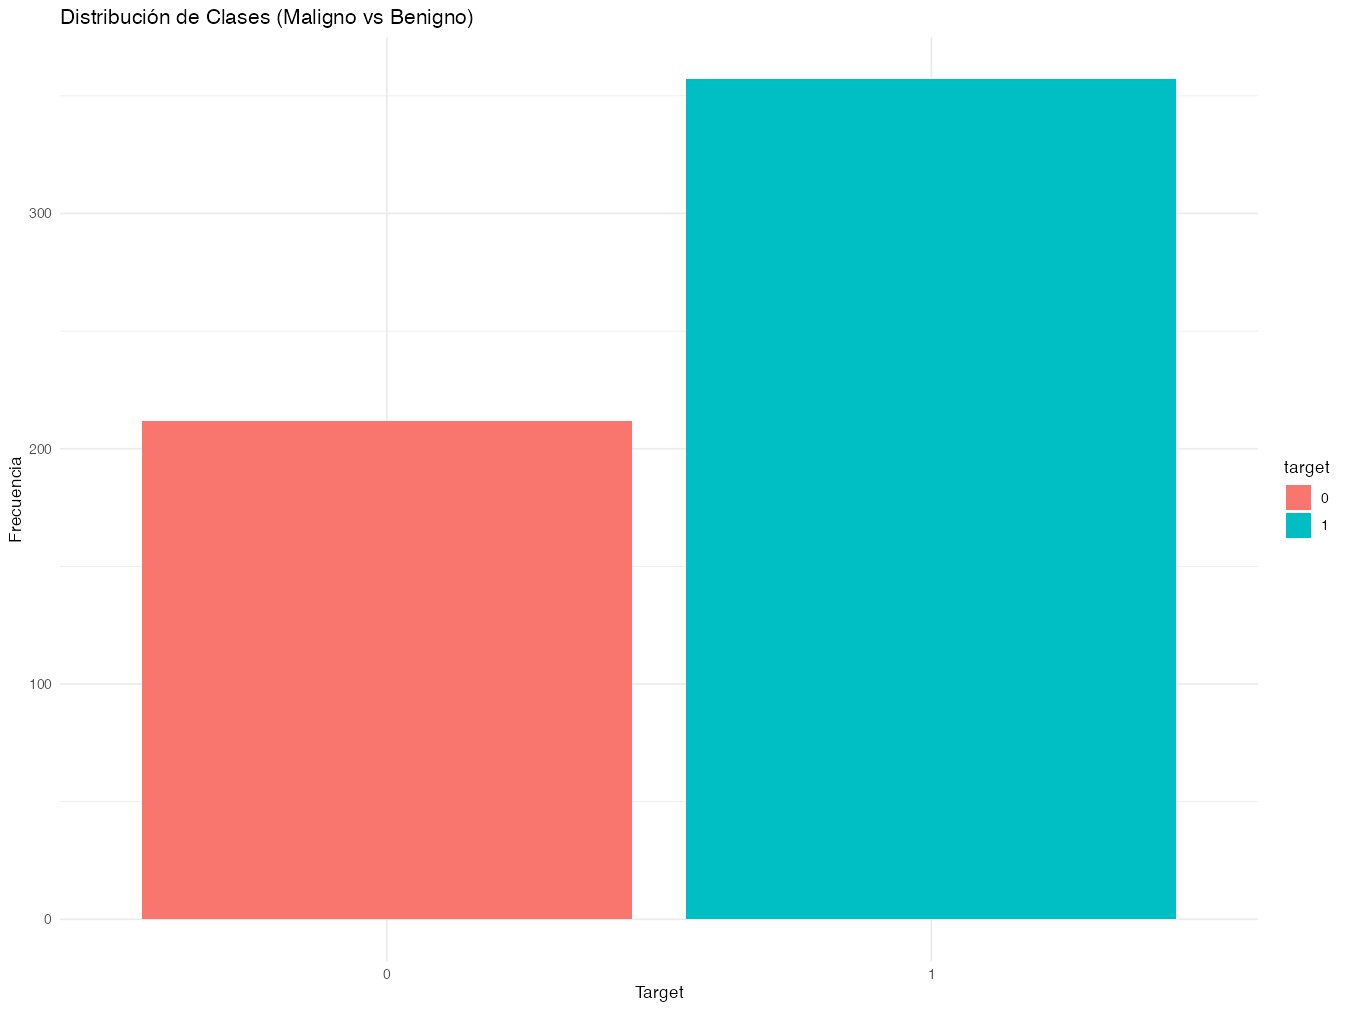

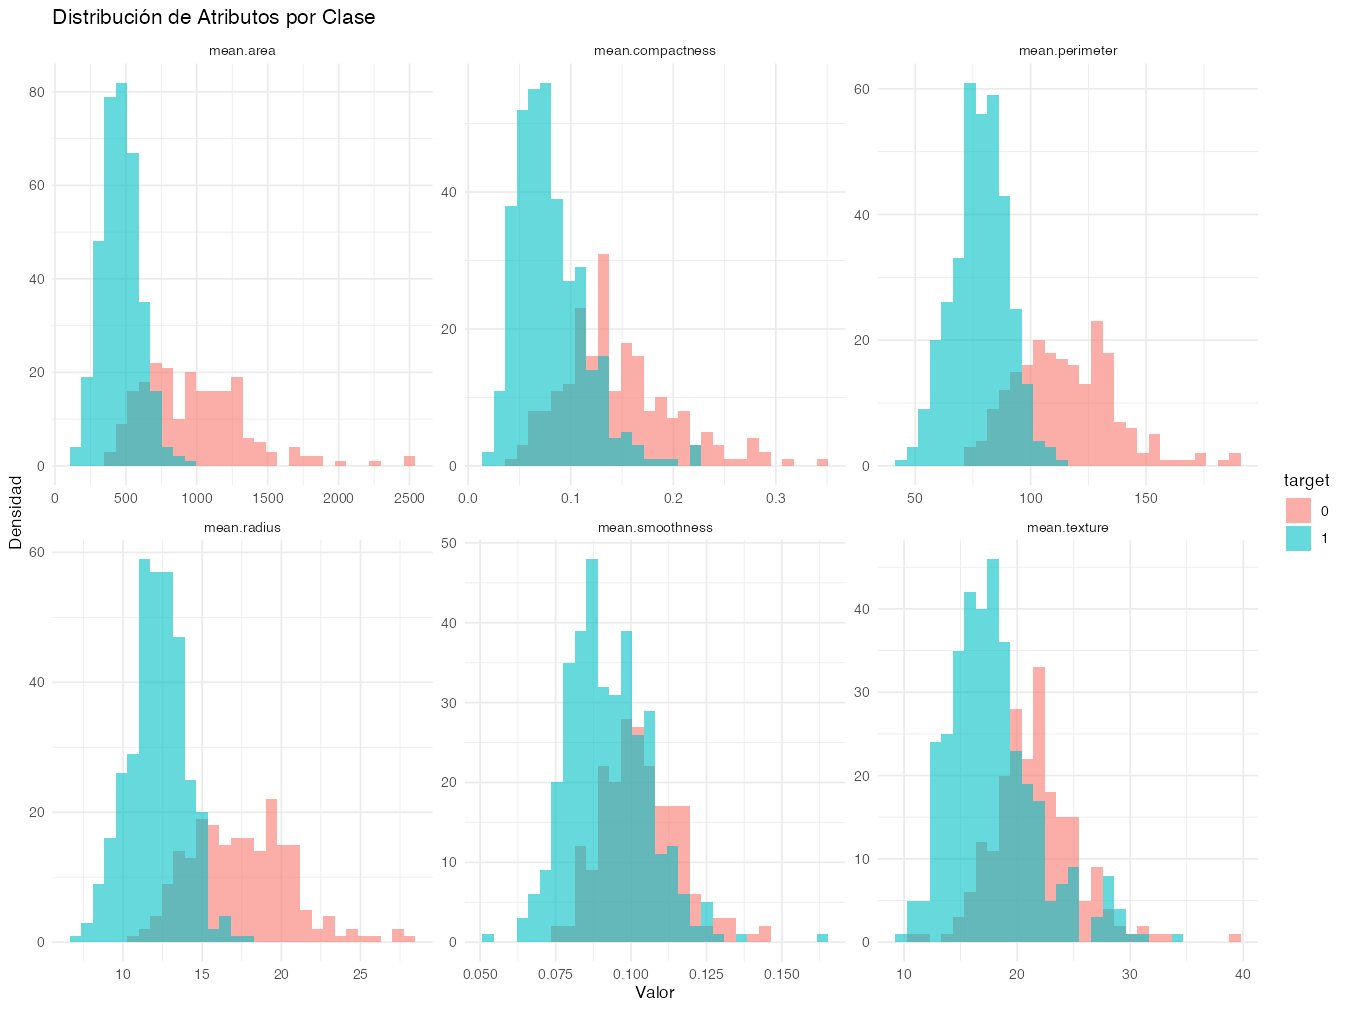

In [4]:
# 6. Análisis Univariante
# Distribución de la variable objetivo
ggplot(data, aes(x = target, fill = target)) +
  geom_bar() +
  labs(title = "Distribución de Clases (Maligno vs Benigno)",
       x = "Target",
       y = "Frecuencia") +
  theme_minimal()

# Histogramas de las variables principales (ejemplo con las primeras 6)
data_long <- data %>%
  select(1:6, target) %>%
  pivot_longer(cols = -target, names_to = "feature", values_to = "value")

ggplot(data_long, aes(x = value, fill = target)) +
  geom_histogram(alpha = 0.6, bins = 30, position = "identity") +
  facet_wrap(~feature, scales = "free") +
  labs(title = "Distribución de Atributos por Clase",
       x = "Valor",
       y = "Densidad") +
  theme_minimal()


--- Generando matriz de correlación ---


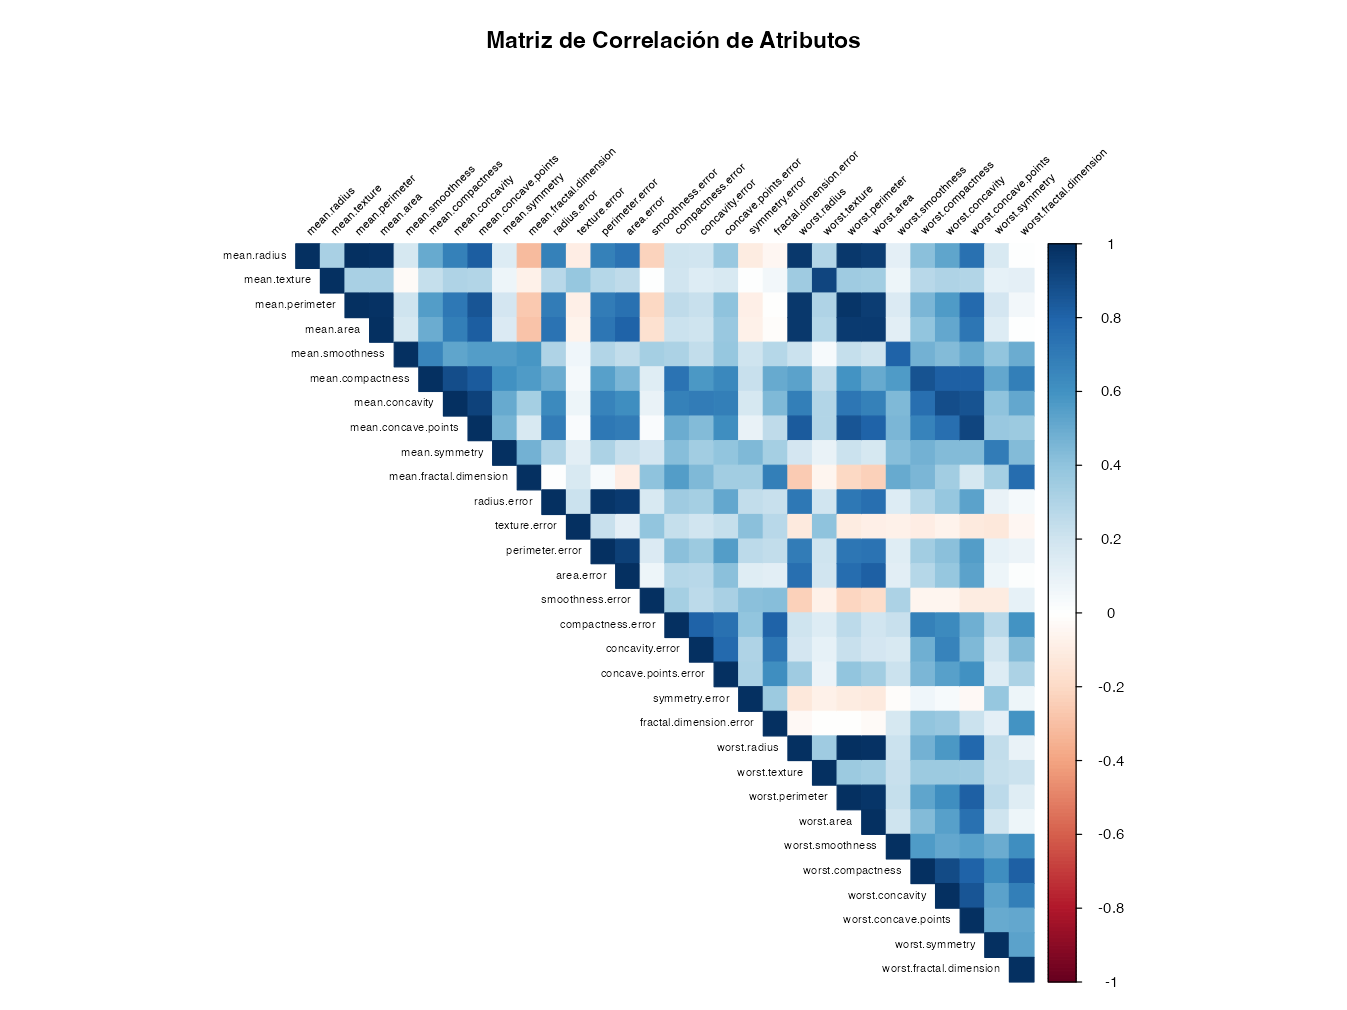

In [5]:
# 7. Análisis Bivariante / Multivariante
# Análisis de correlación entre variables numéricas
numeric_data <- data %>% select_if(is.numeric)
cor_matrix <- cor(numeric_data)

cat("\n--- Generando matriz de correlación ---\n")
corrplot(cor_matrix, method = "color", type = "upper", 
         tl.col = "black", tl.srt = 45, tl.cex = 0.6,
         title = "\n\nMatriz de Correlación de Atributos",
         mar = c(0,0,1,0))

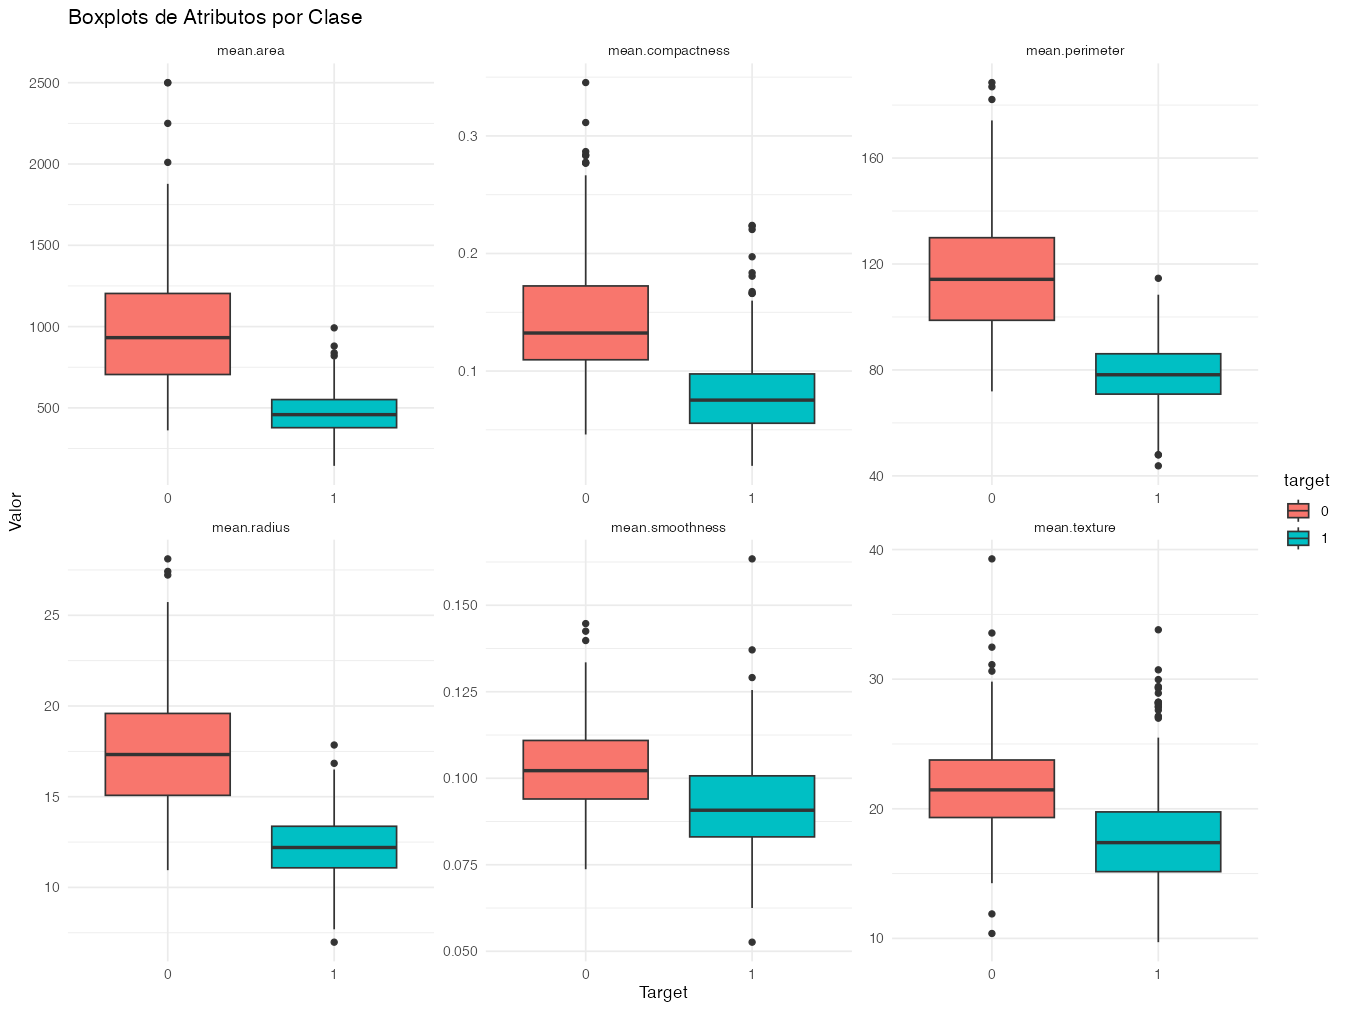

In [6]:
# 8. Detección de Outliers (Valores atípicos)
# Boxplots para identificar la dispersión y valores extremos
ggplot(data_long, aes(x = target, y = value, fill = target)) +
  geom_boxplot() +
  facet_wrap(~feature, scales = "free") +
  labs(title = "Boxplots de Atributos por Clase",
       x = "Target",
       y = "Valor") +
  theme_minimal()

In [7]:
# 9. Resumen de conclusiones preliminares
cat("\n--- EDA Finalizado ---\n")
cat("Sugerencias: \n")
cat("1. Verifique si existe multicolinealidad alta (>0.9) para reducción de dimensiones.\n")
cat("2. Evalúe el escalamiento de variables antes de modelar, dado que los rangos varían considerablemente.\n")


--- EDA Finalizado ---
Sugerencias: 
1. Verifique si existe multicolinealidad alta (>0.9) para reducción de dimensiones.
2. Evalúe el escalamiento de variables antes de modelar, dado que los rangos varían considerablemente.
